source: https://github.com/nytimes/presidential-precinct-map-2024?tab=readme-ov-file

Each precinct in the data has the following properties:

**state**: state postal abbreviation

**GEOID**: unique identifier for the precinct, formed from the five-digit county F.I.P.S. code followed by the precinct name/ID (e.g., 30003-08 or 39091-WEST MANSFIELD)

**votes_dem**: votes received by Kamala Harris

**votes_rep**: votes received by Donald J. Trump

**votes_total**: total votes in the precinct, including for third-party candidates and write-ins when available

**pct_dem_lead**: (votes_dem - votes_rep) / (votes_total), with four significant digits (e.g., -0.2134)

**official_boundary**: true if the precinct’s shape came from a file that was provided by the state or county, false if the precinct boundary was estimated (see caveats below)

In [1]:
import pandas as pd
import numpy as np
import geopandas

In [2]:
df = geopandas.read_file("../data/Georgia/Precinct/ga_nyt.geojson")

In [3]:
offical_boundry = df['official_boundary'].unique()
offical_boundry

array([False,  True])

In [4]:
print(f"shape:{df.shape}")
df.head()

shape:(2680, 8)


,state,GEOID,votes_dem,votes_rep,votes_total,pct_dem_lead,official_boundary,geometry
0,GA,13001-4B,25,720,745,-0.9329,False,"POLYGON ((-82.31151 31.59099, -82.31149 31.590..."
1,GA,13001-5B,82,643,727,-0.7717,False,"POLYGON ((-82.40153 31.69729, -82.40206 31.697..."
2,GA,13001-3C,246,934,1183,-0.5816,False,"POLYGON ((-82.13346 31.6308, -82.13346 31.6308..."
3,GA,13001-2,782,541,1327,0.1816,False,"POLYGON ((-82.28049 31.84937, -82.2805 31.8493..."
4,GA,13001-1B,108,921,1031,-0.7886,False,"POLYGON ((-82.29335 31.94084, -82.29344 31.940..."


<Axes: >

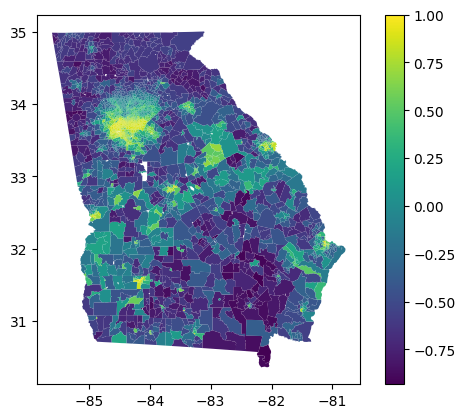

In [5]:
df.plot(column="pct_dem_lead", legend=True)

In [6]:
columns_needed = ['GEOID', 'geometry']
df_precincts = df[columns_needed]

In [7]:
df_precincts

,GEOID,geometry
0,13001-4B,"POLYGON ((-82.31151 31.59099, -82.31149 31.590..."
1,13001-5B,"POLYGON ((-82.40153 31.69729, -82.40206 31.697..."
2,13001-3C,"POLYGON ((-82.13346 31.6308, -82.13346 31.6308..."
3,13001-2,"POLYGON ((-82.28049 31.84937, -82.2805 31.8493..."
4,13001-1B,"POLYGON ((-82.29335 31.94084, -82.29344 31.940..."
...,...,...
2675,13321-01,"POLYGON ((-83.99673 31.5398, -83.99672 31.5398..."
2676,13321-09,"POLYGON ((-83.79721 31.72736, -83.7972 31.7276..."
2677,13321-03,"POLYGON ((-83.73692 31.62228, -83.73693 31.622..."
2678,13321-15,"POLYGON ((-83.89245 31.64641, -83.89212 31.646..."


In [ ]:
df_precincts.to_file("Georgia_precincts.geojson", driver="GeoJSON")